In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.isnull().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

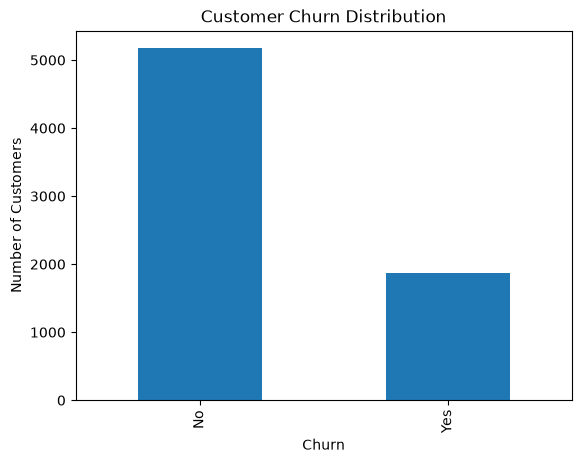

In [11]:
df["Churn"].value_counts().plot(
    kind="bar",
    title="Customer Churn Distribution"
)

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100



Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [13]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100


Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [14]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [15]:
df.groupby("Churn")[["tenure", "MonthlyCharges"]].mean()

,tenure,MonthlyCharges
Churn,,
No,37.569965,61.265124
Yes,17.979133,74.441332


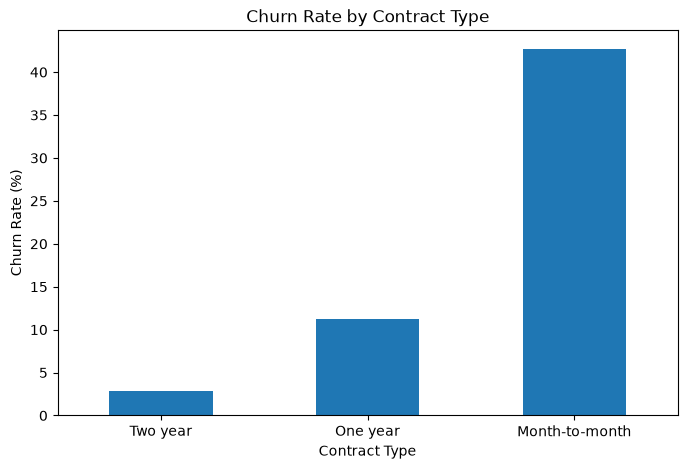

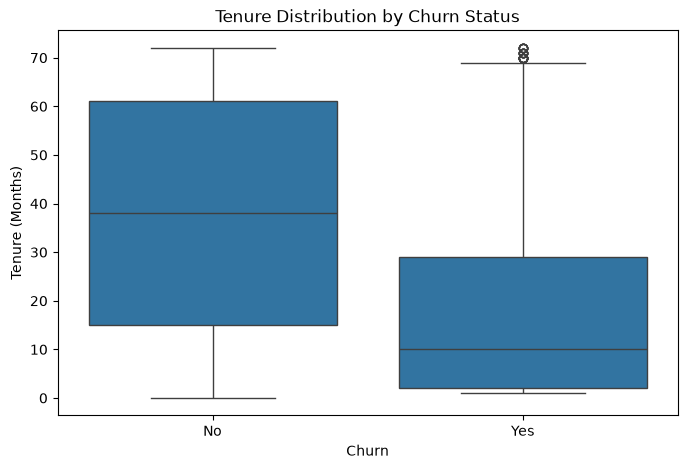

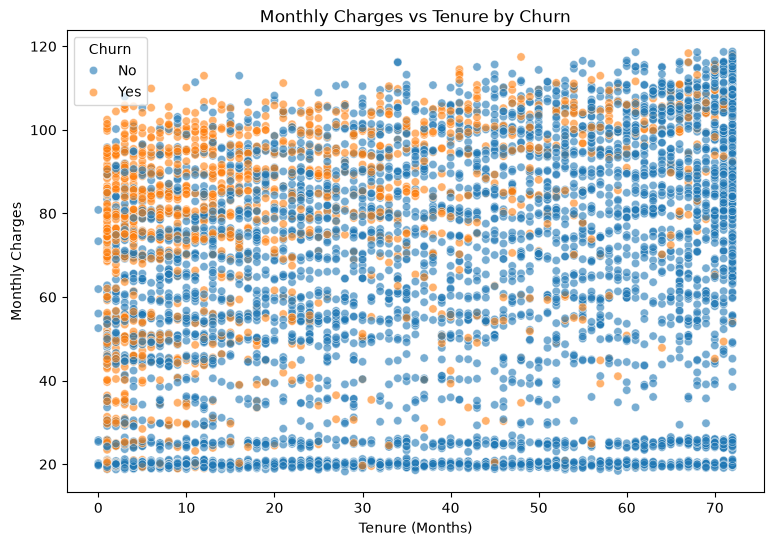

In [18]:
churn_by_contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

churn_by_contract["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8, 5),
    title="Churn Rate by Contract Type"
)

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.6
)

plt.title("Monthly Charges vs Tenure by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")

plt.show()


In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df["TotalCharges"].isnull().sum()
df[df["TotalCharges"].isnull()]
df[df["TotalCharges"].isnull()][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df.isnull().sum()
df = df.drop(columns=["customerID"], errors="ignore")


np.int64(22)

In [38]:
print(df.shape)
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

(7043, 20)
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Duplicates: 22


In [40]:
df[df.duplicated(keep=False)].sort_values(
    by=["gender", "tenure", "MonthlyCharges"]
)
df = df.drop_duplicates()

In [41]:
print("Shape:", df.shape)
print("Duplicates:", df.duplicated().sum())

Shape: (7021, 20)
Duplicates: 0


In [43]:
X = df.drop(columns=["Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})
print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())


X shape: (7021, 19)
y shape: (7021,)
Churn
0    5164
1    1857
Name: count, dtype: int64


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (5616, 19)
Test set: (1405, 19)

Training target distribution:
Churn
0    0.735577
1    0.264423
Name: proportion, dtype: float64

Test target distribution:
Churn
0    0.735231
1    0.264769
Name: proportion, dtype: float64


In [45]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\iT\AppData\Local\Temp\ipykernel_21196\1124402278.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [46]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    drop="first"
)

In [48]:
X_train_encoded = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_encoded = encoder.transform(
    X_test[categorical_features]
)

In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [55]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8021352313167259
Precision: 0.6598639455782312
Recall: 0.521505376344086
F1 Score: 0.5825825825825826
ROC-AUC: 0.8403530275114762


[[933 100]
 [178 194]]


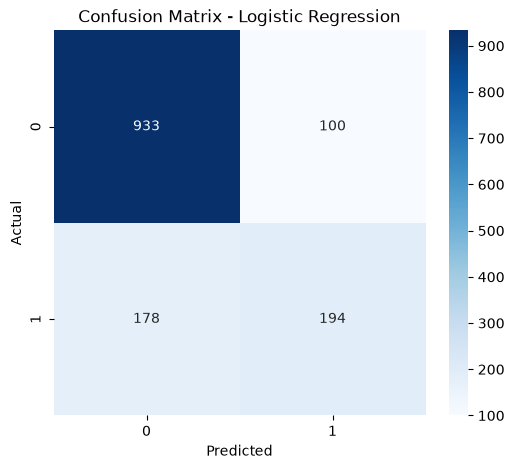

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [60]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest_model.fit(X_train, y_train)
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.7786476868327402
Precision: 0.6133828996282528
Recall: 0.4435483870967742
F1 Score: 0.514820592823713
ROC-AUC: 0.8190102946840293


In [61]:
from xgboost import XGBClassifier
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            eval_metric="logloss"
        )
    )
])
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))


Accuracy: 0.800711743772242
Precision: 0.6564625850340136
Recall: 0.5188172043010753
F1 Score: 0.5795795795795796
ROC-AUC: 0.8402983792898853


In [62]:
logistic_balanced = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])
logistic_balanced.fit(X_train, y_train)
balanced_pred = logistic_balanced.predict(X_test)
balanced_prob = logistic_balanced.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, balanced_pred))
print("Precision:", precision_score(y_test, balanced_pred))
print("Recall:", recall_score(y_test, balanced_pred))
print("F1 Score:", f1_score(y_test, balanced_pred))
print("ROC-AUC:", roc_auc_score(y_test, balanced_prob))


Accuracy: 0.7409252669039146
Precision: 0.506993006993007
Recall: 0.7795698924731183
F1 Score: 0.614406779661017
ROC-AUC: 0.8398455797395622


In [63]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    threshold_pred = (balanced_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Precision:", precision_score(y_test, threshold_pred))
    print("Recall:", recall_score(y_test, threshold_pred))
    print("F1:", f1_score(y_test, threshold_pred))


Threshold: 0.3
Precision: 0.425273390036452
Recall: 0.9408602150537635
F1: 0.5857740585774058

Threshold: 0.4
Precision: 0.46589259796806964
Recall: 0.8629032258064516
F1: 0.6050895381715363

Threshold: 0.5
Precision: 0.506993006993007
Recall: 0.7795698924731183
F1: 0.614406779661017

Threshold: 0.6
Precision: 0.5485961123110151
Recall: 0.6827956989247311
F1: 0.6083832335329341

Threshold: 0.7
Precision: 0.6137724550898204
Recall: 0.5510752688172043
F1: 0.5807365439093485


In [65]:
fitted_preprocessor = logistic_balanced.named_steps["preprocessor"]

X_train_transformed = fitted_preprocessor.transform(X_train)

feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print(feature_names[:20])
import shap

classifier = logistic_balanced.named_steps["classifier"]

X_train_dense = (
    X_train_transformed.toarray()
    if hasattr(X_train_transformed, "toarray")
    else X_train_transformed
)

explainer = shap.Explainer(
    classifier,
    X_train_dense,
    feature_names=feature_names
)

shap_values = explainer(X_train_dense)

print("SHAP values shape:", shap_values.values.shape)

Number of transformed features: 30
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Male' 'cat__Partner_Yes'
 'cat__Dependents_Yes' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__OnlineBackup_No internet service' 'cat__OnlineBackup_Yes'
 'cat__DeviceProtection_No internet service' 'cat__DeviceProtection_Yes'
 'cat__TechSupport_No internet service' 'cat__TechSupport_Yes']


Background dataset has 5616 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5616 when initializing the masker.


SHAP values shape: (5616, 30)


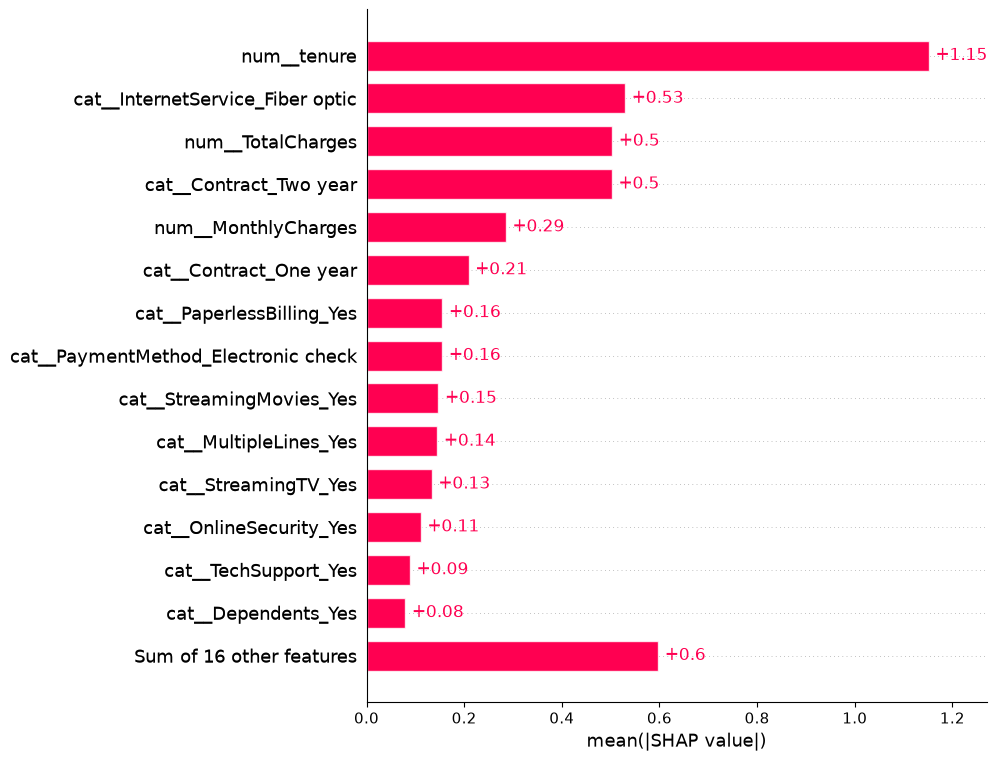

In [66]:
shap.plots.bar(
    shap_values,
    max_display=15
)

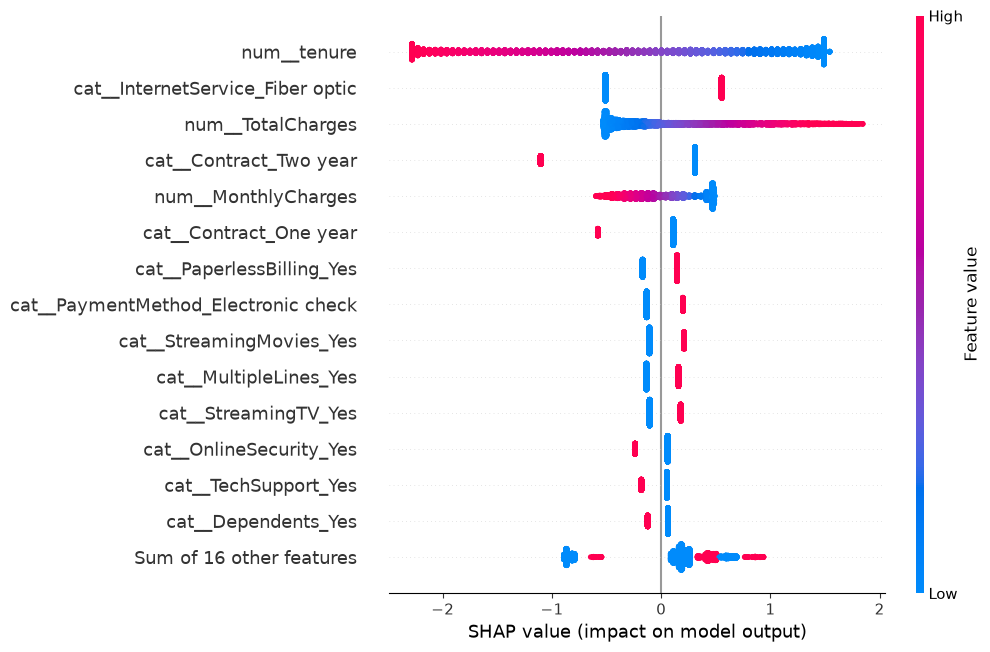

In [67]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

gender                          Male
SeniorCitizen                      1
Partner                          Yes
Dependents                        No
tenure                             7
PhoneService                     Yes
MultipleLines                    Yes
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                       No
StreamingMovies                   No
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                 74.85
TotalCharges                  485.25
Name: 5627, dtype: object

Actual Churn: 0
Predicted Probability: 0.888320627740692


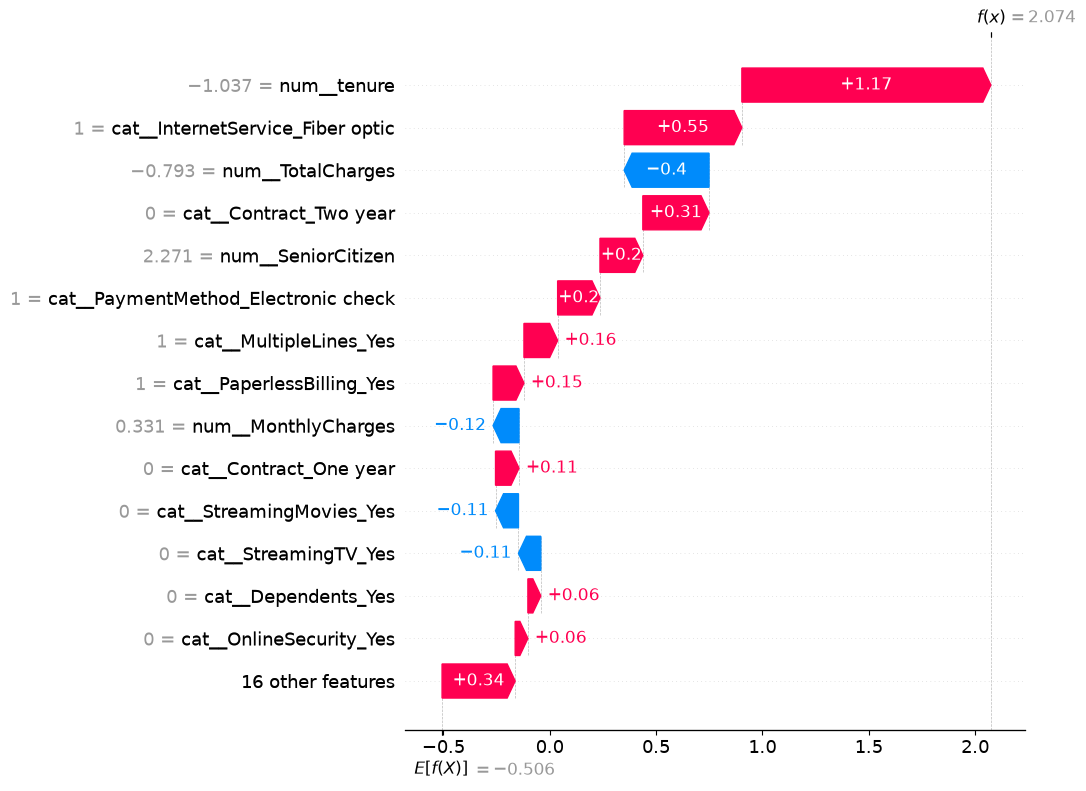

In [69]:
customer_index = 0

print(X_test.iloc[customer_index])
print("\nActual Churn:", y_test.iloc[customer_index])
print("Predicted Probability:", balanced_prob[customer_index])

X_customer = X_test.iloc[[customer_index]]

X_customer_transformed = fitted_preprocessor.transform(X_customer)

X_customer_dense = (
    X_customer_transformed.toarray()
    if hasattr(X_customer_transformed, "toarray")
    else X_customer_transformed
)

customer_shap = explainer(X_customer_dense)

shap.plots.waterfall(
    customer_shap[0],
    max_display=15
)

In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

models = {
    "Logistic Regression": (y_pred, y_prob),
    "Random Forest": (rf_pred, rf_prob),
    "XGBoost": (xgb_pred, xgb_prob),
    "Balanced Logistic Regression": (balanced_pred, balanced_prob)
}

for model_name, (pred, prob) in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802135,0.659864,0.521505,0.582583,0.840353
1,Random Forest,0.778648,0.613383,0.443548,0.514821,0.819010
2,XGBoost,0.800712,0.656463,0.518817,0.579580,0.840298
3,Balanced Logistic Regression,0.740925,0.506993,0.779570,0.614407,0.839846
